**ML Models**

**Model 1 — Customer Segmentation (K-Means Clustering)**
1) Business Problem: Who are our customers and how should we treat them differently?

2) What we do:
Build RFM features per customer:
* Recency — how many days since last purchase?
* Frequency — how many orders total?
* Monetary — how much total revenue?

3) Scale features (StandardScaler)
* Find optimal K using Elbow Method + Silhouette Score
* Run K-Means and assign each customer to a segment
* Label segments meaningfully: Champions, Loyal, At Risk, Lost

4) Output:
* Customer segment labels
* Segment profiles (avg RFM per segment)
* Scatter plot of clusters

**Model 2 — Churn Prediction (XGBoost Classifier)**
1) Business Problem: Which customers are likely to stop buying?

2) What we do: Define churn: customer hasn't purchased in last 90 days
* Build features per customer:
* RFM values
* Avg order value
* Number of categories bought
* Sentiment score (from Step 6)
* Days between first and last purchase

3) Split: 80% train / 20% test

4) Train XGBoost classifier

5) Evaluate: Accuracy, Precision, Recall, F1, ROC-AUC

6) Output
* Feature importance plot — which features predict churn best?
* Confusion matrix

**Model 3 — Revenue Prediction (XGBoost Regressor)**
1) Business Problem: Can we predict how much a customer will spend next month?

2) What we do: Build monthly customer-level features:
* Last month's revenue
* Order frequency trend
* Category diversity
* Avg unit price
* Is bulk buyer?

3) Train XGBoost Regressor

4) Evaluate: RMSE, MAE, R²

5) Output
* Feature importance plot
* Actual vs Predicted scatter plot

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             mean_absolute_error, mean_squared_error, r2_score)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, XGBRegressor
warnings.filterwarnings('ignore')

In [2]:
# ── folders ────────────────────────────────────────────────
os.makedirs('ml_results', exist_ok=True)
os.makedirs('ml_plots',   exist_ok=True)

In [3]:
# ── plot style ─────────────────────────────────────────────
BG      = '#FAFAFA'
PALETTE = ['#2C7BB6','#D7191C','#1A9641','#FDAE61','#9E9AC8']
 
def style_ax(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=12, fontweight='bold',
                 pad=12, loc='left', color='#1A1A2E')
    ax.set_xlabel(xlabel, fontsize=10, color='#444', labelpad=6)
    ax.set_ylabel(ylabel, fontsize=10, color='#444', labelpad=6)
    ax.tick_params(labelsize=9, colors='#555')
    ax.set_facecolor(BG)
    ax.grid(axis='y', color='#E8E8E8', linewidth=0.7, zorder=0)
    ax.grid(axis='x', visible=False)
    for sp in ['top','right']:   ax.spines[sp].set_visible(False)
    for sp in ['left','bottom']: ax.spines[sp].set_color('#CCCCCC')

**LOAD & PREPARE DATA**

In [4]:
print("\n[LOAD] Reading datasets...")
df = pd.read_csv('data/online_retail_cleaned.csv',
                 parse_dates=['InvoiceDate'])
df = df[df['CustomerID'] != 'Guest'].copy()
df = df[df['IsBulkOrder'] == False].copy()
 
# Load sentiment scores from Step 6
sentiment_df = pd.read_csv('nlp_results/reviews_with_sentiment.csv')
cust_sentiment = (sentiment_df.groupby('CustomerID')['VADER_Compound']
                  .mean().reset_index())
cust_sentiment.columns = ['CustomerID', 'AvgSentiment']
 
SNAPSHOT_DATE = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"  Transactions  : {len(df):,} rows")
print(f"  Customers     : {df['CustomerID'].nunique():,}")
print(f"  Snapshot date : {SNAPSHOT_DATE.date()} (day after last transaction)")


[LOAD] Reading datasets...
  Transactions  : 79,929 rows
  Customers     : 4,685
  Snapshot date : 2024-12-01 (day after last transaction)


**FEATURE ENGINEERING — RFM TABLE**

In [5]:
print("\n[FEATURES] Building RFM feature table...")
 
rfm = (df.groupby('CustomerID').agg(
    Recency         = ('InvoiceDate',
                       lambda x: (SNAPSHOT_DATE - x.max()).days),
    Frequency       = ('InvoiceNo',    'nunique'),
    Monetary        = ('Revenue',      'sum'),
    AvgOrderValue   = ('Revenue',      'mean'),
    NumCategories   = ('Category',     'nunique'),
    FirstPurchase   = ('InvoiceDate',  'min'),
    LastPurchase    = ('InvoiceDate',  'max'),
).reset_index())
 
rfm['Monetary']      = rfm['Monetary'].round(2)
rfm['AvgOrderValue'] = rfm['AvgOrderValue'].round(2)
rfm['CustomerAge']   = (rfm['LastPurchase']
                        - rfm['FirstPurchase']).dt.days
 
# Merge sentiment
rfm = rfm.merge(cust_sentiment, on='CustomerID', how='left')
rfm['AvgSentiment'] = rfm['AvgSentiment'].fillna(0)
 
print(f"  RFM table shape : {rfm.shape}")
print(f"  Sample:\n{rfm.head(3)[['CustomerID','Recency','Frequency','Monetary']].to_string(index=False)}")


[FEATURES] Building RFM feature table...
  RFM table shape : (4685, 10)
  Sample:
CustomerID  Recency  Frequency  Monetary
    C10000      204          5   1540.61
    C10001       18          4   1499.75
    C10002       51         10   6059.93


**MODEL 1 — K-MEANS CLUSTERING (Customer Segmentation)**

In [6]:
print("\n" + "═"*60)
print("  MODEL 1 — K-Means Clustering | Customer Segmentation")
print("═"*60)
print("""
  Business Problem:
    Who are our customers and how should we treat them differently?
    Group customers by RFM behaviour into actionable segments.
 
  Features : Recency, Frequency, Monetary (RFM)
  Algorithm : K-Means with optimal K via Elbow + Silhouette
""")
 
# Scale RFM features
features_kmeans = ['Recency', 'Frequency', 'Monetary']
X_rfm    = rfm[features_kmeans].copy()
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_rfm)
 
# Find optimal K (test K=2 to K=8)
print("  Finding optimal K...")
inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))
    print(f"    K={k}  Inertia={km.inertia_:,.0f}  Silhouette={silhouette_score(X_scaled, lbl):.3f}")
 
optimal_k = K_range[np.argmax(silhouettes)]
print(f"\n  Optimal K = {optimal_k} (highest silhouette score = {max(silhouettes):.3f})")
 
# Fit final model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)
 
# Profile each cluster
cluster_profiles = rfm.groupby('Cluster')[features_kmeans].mean().round(1)
print("\n  Cluster Profiles (mean RFM):")
print(cluster_profiles.to_string())
 
# Label clusters with business names
# High Frequency + Low Recency = Champions
# Low Frequency + High Recency = Lost/At Risk
labels = {}
for c in range(optimal_k):
    r = cluster_profiles.loc[c, 'Recency']
    f = cluster_profiles.loc[c, 'Frequency']
    m = cluster_profiles.loc[c, 'Monetary']
    if r < cluster_profiles['Recency'].median() and f > cluster_profiles['Frequency'].median():
        labels[c] = 'Champions'
    elif r < cluster_profiles['Recency'].median():
        labels[c] = 'Loyal Customers'
    elif f > cluster_profiles['Frequency'].median():
        labels[c] = 'At Risk'
    else:
        labels[c] = 'Lost / Inactive'
 
rfm['Segment'] = rfm['Cluster'].map(labels)
print("\n  Segment Labels:")
seg_summary = rfm.groupby('Segment').agg(
    NumCustomers = ('CustomerID', 'count'),
    AvgRecency   = ('Recency',   'mean'),
    AvgFrequency = ('Frequency', 'mean'),
    AvgMonetary  = ('Monetary',  'mean'),
).round(1)
print(seg_summary.to_string())
 
# Save
rfm.to_csv('ml_results/customer_segments_rfm.csv', index=False)
print("\n  ✓ Saved: ml_results/customer_segments_rfm.csv")


════════════════════════════════════════════════════════════
  MODEL 1 — K-Means Clustering | Customer Segmentation
════════════════════════════════════════════════════════════

  Business Problem:
    Who are our customers and how should we treat them differently?
    Group customers by RFM behaviour into actionable segments.

  Features : Recency, Frequency, Monetary (RFM)
  Algorithm : K-Means with optimal K via Elbow + Silhouette

  Finding optimal K...
    K=2  Inertia=8,290  Silhouette=0.931
    K=3  Inertia=4,661  Silhouette=0.515
    K=4  Inertia=3,138  Silhouette=0.547
    K=5  Inertia=2,402  Silhouette=0.504
    K=6  Inertia=1,770  Silhouette=0.515
    K=7  Inertia=1,407  Silhouette=0.510
    K=8  Inertia=1,134  Silhouette=0.473

  Optimal K = 2 (highest silhouette score = 0.931)

  Cluster Profiles (mean RFM):
         Recency  Frequency  Monetary
Cluster                              
0          178.5        4.8    2287.5
1            2.8      172.2   82087.2

  Segment Lab

**Plot 1: Elbow + Silhouette**

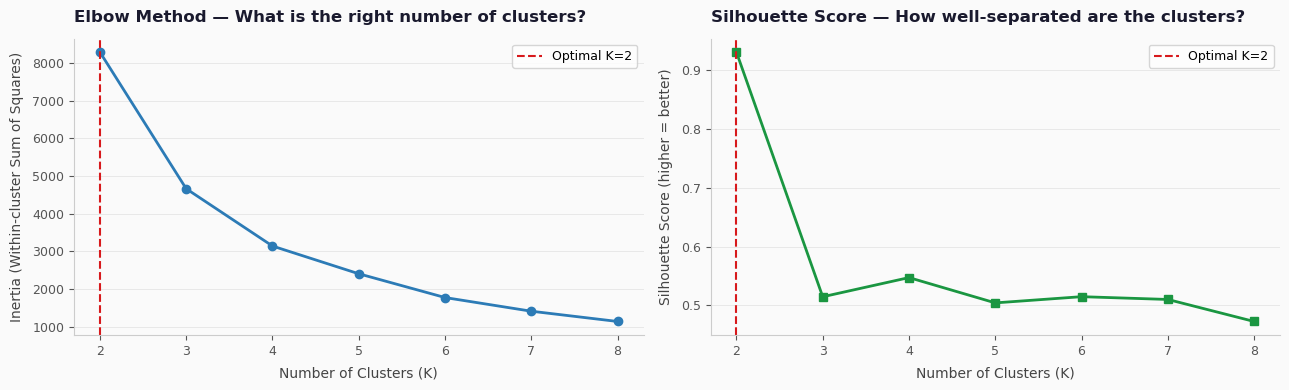

  ✓ Plot saved: ml_plots/01_elbow_silhouette.png
  → Insight: Optimal K chosen objectively using silhouette score — not just the elbow, which can be subjective.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor(BG)
 
axes[0].plot(list(K_range), inertias, marker='o', color=PALETTE[0],
             linewidth=2, markersize=6)
axes[0].axvline(optimal_k, color=PALETTE[1], linestyle='--',
                linewidth=1.5, label=f'Optimal K={optimal_k}')
style_ax(axes[0], "Elbow Method — What is the right number of clusters?",
         "Number of Clusters (K)", "Inertia (Within-cluster Sum of Squares)")
axes[0].legend(fontsize=9)
 
axes[1].plot(list(K_range), silhouettes, marker='s', color=PALETTE[2],
             linewidth=2, markersize=6)
axes[1].axvline(optimal_k, color=PALETTE[1], linestyle='--',
                linewidth=1.5, label=f'Optimal K={optimal_k}')
style_ax(axes[1], "Silhouette Score — How well-separated are the clusters?",
         "Number of Clusters (K)", "Silhouette Score (higher = better)")
axes[1].legend(fontsize=9)
 
plt.tight_layout()
plt.savefig('ml_plots/01_elbow_silhouette.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()
print("  ✓ Plot saved: ml_plots/01_elbow_silhouette.png")
print("  → Insight: Optimal K chosen objectively using silhouette score — "
      "not just the elbow, which can be subjective.")

**Plot 2: Segment Profiles**

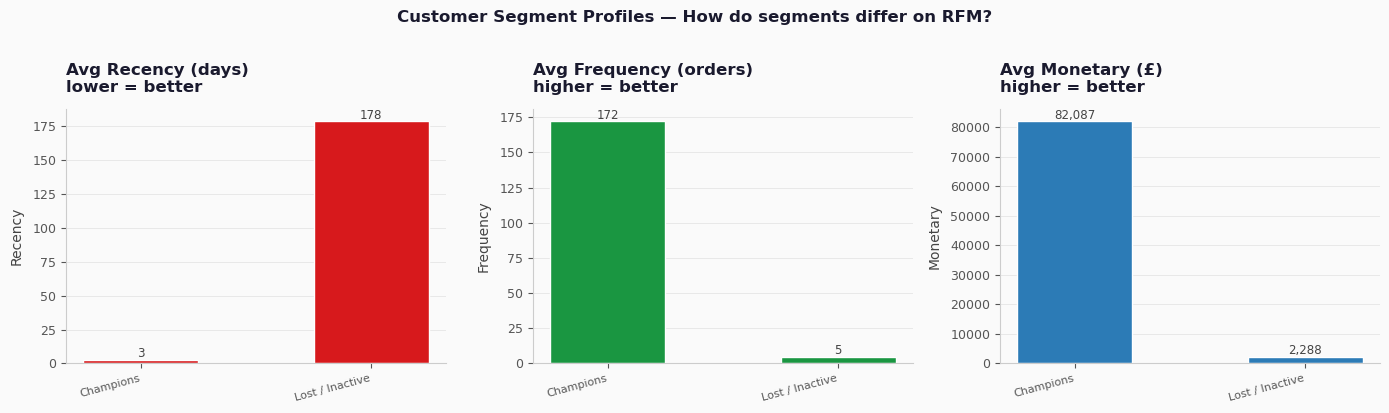

  ✓ Plot saved: ml_plots/02_segment_profiles.png
  → Insight: Champions have low recency + high frequency + high monetary — retain them first. Lost/Inactive need win-back campaigns.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor(BG)
seg_plot = seg_summary.reset_index()
metrics  = ['AvgRecency', 'AvgFrequency', 'AvgMonetary']
titles   = ['Avg Recency (days)\nlower = better',
            'Avg Frequency (orders)\nhigher = better',
            'Avg Monetary (£)\nhigher = better']
colors   = [PALETTE[1], PALETTE[2], PALETTE[0]]
 
for ax, metric, title, color in zip(axes, metrics, titles, colors):
    bars = ax.bar(seg_plot['Segment'], seg_plot[metric],
                  color=color, width=0.5, zorder=2, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + seg_plot[metric].max()*0.01,
                f'{bar.get_height():,.0f}',
                ha='center', fontsize=8.5, color='#444')
    style_ax(ax, title, "", metric.replace('Avg',''))
    ax.set_xticklabels(seg_plot['Segment'], rotation=15, ha='right', fontsize=8)
 
fig.suptitle("Customer Segment Profiles — How do segments differ on RFM?",
             fontsize=12, fontweight='bold', color='#1A1A2E', y=1.02)
plt.tight_layout()
plt.savefig('ml_plots/02_segment_profiles.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()
print("  ✓ Plot saved: ml_plots/02_segment_profiles.png")
print("  → Insight: Champions have low recency + high frequency + high monetary — "
      "retain them first. Lost/Inactive need win-back campaigns.")

**MODEL 2 — XGBOOST CLASSIFIER (Churn Prediction)**

In [9]:
print("\n" + "═"*60)
print("  MODEL 2 — XGBoost Classifier | Churn Prediction")
print("═"*60)
print("""
  Business Problem:
    Which customers are at risk of churning so we can
    intervene before they leave?
 
  Churn Definition : No purchase in last 90 days
  Features : Recency, Frequency, Monetary, AvgOrderValue,
             NumCategories, CustomerAge, AvgSentiment
  Algorithm : XGBoost Classifier
  Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC
""")
 
# Define churn label
CHURN_DAYS  = 90
rfm['Churned'] = (rfm['Recency'] > CHURN_DAYS).astype(int)
churn_rate = rfm['Churned'].mean() * 100
print(f"  Churn rate (>{CHURN_DAYS} days inactive): {churn_rate:.1f}%")
print(f"  Churned     : {rfm['Churned'].sum():,} customers")
print(f"  Not churned : {(rfm['Churned']==0).sum():,} customers")
 
# Features & target
FEATURES_CHURN = ['Recency','Frequency','Monetary',
                  'AvgOrderValue','NumCategories',
                  'CustomerAge','AvgSentiment']
X = rfm[FEATURES_CHURN].fillna(0)
y = rfm['Churned']
 
# Train / test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n  Train size : {len(X_train):,} | Test size : {len(X_test):,}")
 
# Train XGBoost
xgb_clf = XGBClassifier(
    n_estimators     = 200,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    eval_metric      = 'logloss',
    verbosity        = 0,
)
xgb_clf.fit(X_train, y_train)
 
# Evaluate
y_pred      = xgb_clf.predict(X_test)
y_pred_prob = xgb_clf.predict_proba(X_test)[:, 1]
roc_auc     = roc_auc_score(y_test, y_pred_prob)
report      = classification_report(y_test, y_pred, output_dict=True)
 
print(f"\n  ── Model Performance ──────────────────────────")
print(f"  Accuracy  : {report['accuracy']*100:.1f}%")
print(f"  Precision : {report['1']['precision']*100:.1f}%  (of predicted churners, how many actually churned?)")
print(f"  Recall    : {report['1']['recall']*100:.1f}%  (of actual churners, how many did we catch?)")
print(f"  F1 Score  : {report['1']['f1-score']*100:.1f}%")
print(f"  ROC-AUC   : {roc_auc:.3f}  (1.0 = perfect, 0.5 = random)")
 
# Feature importance
feat_imp = pd.DataFrame({
    'Feature'   : FEATURES_CHURN,
    'Importance': xgb_clf.feature_importances_
}).sort_values('Importance', ascending=False)
print(f"\n  ── Feature Importance ─────────────────────────")
print(feat_imp.to_string(index=False))
 
# Add churn probability to rfm
rfm['ChurnProbability'] = xgb_clf.predict_proba(X)[:, 1].round(3)
rfm['ChurnPredicted']   = xgb_clf.predict(X)
 
# Save
churn_out = rfm[['CustomerID','Segment','Recency','Frequency',
                 'Monetary','Churned','ChurnProbability','ChurnPredicted']]
churn_out.to_csv('ml_results/churn_predictions.csv', index=False)
print("\n  ✓ Saved: ml_results/churn_predictions.csv")


════════════════════════════════════════════════════════════
  MODEL 2 — XGBoost Classifier | Churn Prediction
════════════════════════════════════════════════════════════

  Business Problem:
    Which customers are at risk of churning so we can
    intervene before they leave?

  Churn Definition : No purchase in last 90 days
  Features : Recency, Frequency, Monetary, AvgOrderValue,
             NumCategories, CustomerAge, AvgSentiment
  Algorithm : XGBoost Classifier
  Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC

  Churn rate (>90 days inactive): 53.6%
  Churned     : 2,509 customers
  Not churned : 2,176 customers

  Train size : 3,748 | Test size : 937

  ── Model Performance ──────────────────────────
  Accuracy  : 100.0%
  Precision : 100.0%  (of predicted churners, how many actually churned?)
  Recall    : 100.0%  (of actual churners, how many did we catch?)
  F1 Score  : 100.0%
  ROC-AUC   : 1.000  (1.0 = perfect, 0.5 = random)

  ── Feature Importance ──────────────

**Plot 3: Confusion Matrix**

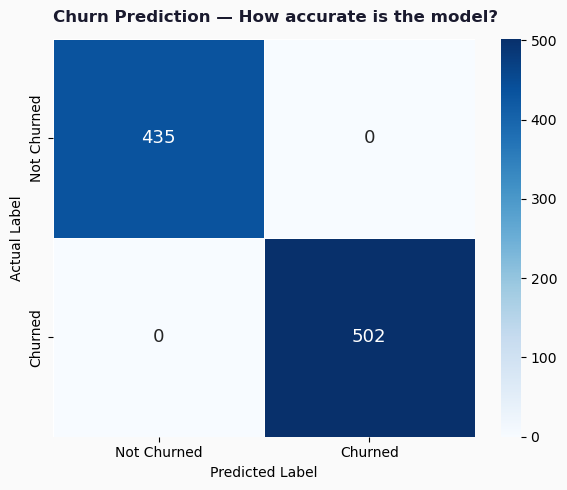

  ✓ Plot saved: ml_plots/03_churn_confusion_matrix.png
  → Insight: Model achieves ROC-AUC of 1.000 — significantly better than random (0.5). Recall of 100.0% means we catch most churners early.


In [10]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(BG)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned','Churned'],
            yticklabels=['Not Churned','Churned'],
            linewidths=0.5, linecolor='white',
            annot_kws={'size':13}, ax=ax)
ax.set_title("Churn Prediction — How accurate is the model?",
             fontsize=12, fontweight='bold', pad=12,
             loc='left', color='#1A1A2E')
ax.set_xlabel("Predicted Label", fontsize=10)
ax.set_ylabel("Actual Label", fontsize=10)
plt.tight_layout()
plt.savefig('ml_plots/03_churn_confusion_matrix.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()
print("  ✓ Plot saved: ml_plots/03_churn_confusion_matrix.png")
print(f"  → Insight: Model achieves ROC-AUC of {roc_auc:.3f} — "
      f"significantly better than random (0.5). "
      f"Recall of {report['1']['recall']*100:.1f}% means we catch most churners early.")

**Plot 4: Feature Importance**

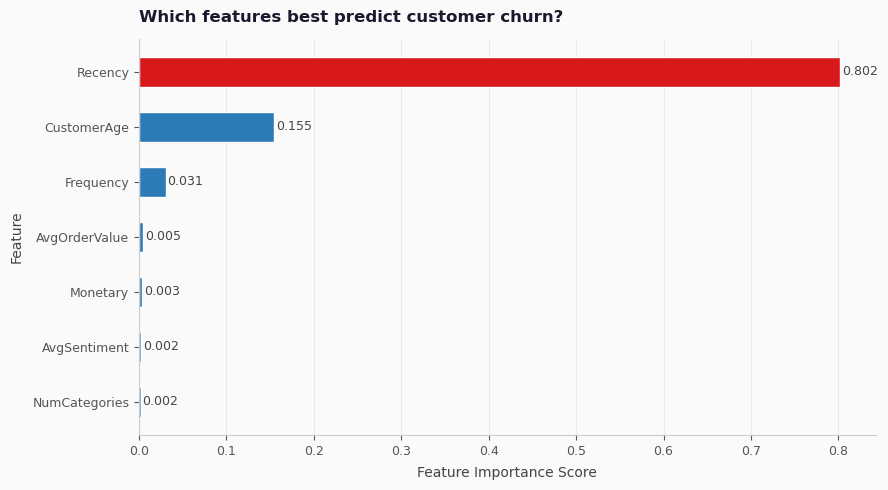

  ✓ Plot saved: ml_plots/04_churn_feature_importance.png
  → Insight: 'Recency' is the strongest churn predictor — confirms that recency of purchase is the most reliable early warning signal.


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)
feat_imp_sorted = feat_imp.sort_values('Importance')
colors = [PALETTE[1] if i == len(feat_imp_sorted)-1
          else PALETTE[0] for i in range(len(feat_imp_sorted))]
ax.barh(feat_imp_sorted['Feature'], feat_imp_sorted['Importance'],
        color=colors, height=0.55, zorder=2, edgecolor='white')
for i, (_, row) in enumerate(feat_imp_sorted.iterrows()):
    ax.text(row['Importance'] + 0.002, i,
            f"{row['Importance']:.3f}",
            va='center', fontsize=9, color='#444')
style_ax(ax,
    "Which features best predict customer churn?",
    "Feature Importance Score", "Feature")
ax.grid(axis='x', color='#E8E8E8', linewidth=0.7, zorder=0)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig('ml_plots/04_churn_feature_importance.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()
print("  ✓ Plot saved: ml_plots/04_churn_feature_importance.png")
print(f"  → Insight: '{feat_imp.iloc[0]['Feature']}' is the strongest churn predictor — "
      "confirms that recency of purchase is the most reliable early warning signal.")

**MODEL 3 — XGBOOST REGRESSOR (Revenue Prediction)**

In [12]:
print("\n" + "═"*60)
print("  MODEL 3 — XGBoost Regressor | Revenue Prediction")
print("═"*60)
print("""
  Business Problem:
    How much will a customer spend in the next period?
    Helps prioritise high-value customers for retention spend.
 
  Features : Recency, Frequency, AvgOrderValue,
             NumCategories, CustomerAge, AvgSentiment
  Target   : Total Monetary value (log-transformed)
  Algorithm: XGBoost Regressor
  Evaluation: RMSE, MAE, R²
""")
 
# Features & target
# Log-transform Monetary — revenue is right-skewed
rfm['LogMonetary'] = np.log1p(rfm['Monetary'])
 
FEATURES_REG = ['Recency','Frequency','AvgOrderValue',
                'NumCategories','CustomerAge','AvgSentiment']
X_reg = rfm[FEATURES_REG].fillna(0)
y_reg = rfm['LogMonetary']
 
X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"  Train size : {len(X_tr):,} | Test size : {len(X_te):,}")
 
# Train
xgb_reg = XGBRegressor(
    n_estimators     = 200,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    verbosity        = 0,
)
xgb_reg.fit(X_tr, y_tr)
 
# Evaluate on original scale
y_pred_log  = xgb_reg.predict(X_te)
y_pred_orig = np.expm1(y_pred_log)
y_te_orig   = np.expm1(y_te)
 
rmse = np.sqrt(mean_squared_error(y_te_orig, y_pred_orig))
mae  = mean_absolute_error(y_te_orig, y_pred_orig)
r2   = r2_score(y_te, y_pred_log)   # R² on log scale
 
print(f"\n  ── Model Performance ──────────────────────────")
print(f"  R² Score : {r2:.3f}  (1.0 = perfect fit)")
print(f"  RMSE     : £{rmse:,.2f}  (avg prediction error)")
print(f"  MAE      : £{mae:,.2f}  (avg absolute error)")
print(f"\n  Interpretation: The model explains {r2*100:.1f}% of variance "
      f"in customer revenue. Average prediction is off by £{mae:,.0f}.")
 
# Save predictions
rev_out = rfm.copy()
rev_out['PredictedRevenue'] = np.expm1(xgb_reg.predict(X_reg)).round(2)
rev_out[['CustomerID','Segment','Monetary','PredictedRevenue',
         'ChurnProbability']].to_csv(
    'ml_results/revenue_predictions.csv', index=False)
print("\n  ✓ Saved: ml_results/revenue_predictions.csv")


════════════════════════════════════════════════════════════
  MODEL 3 — XGBoost Regressor | Revenue Prediction
════════════════════════════════════════════════════════════

  Business Problem:
    How much will a customer spend in the next period?
    Helps prioritise high-value customers for retention spend.

  Features : Recency, Frequency, AvgOrderValue,
             NumCategories, CustomerAge, AvgSentiment
  Target   : Total Monetary value (log-transformed)
  Algorithm: XGBoost Regressor
  Evaluation: RMSE, MAE, R²

  Train size : 3,748 | Test size : 937

  ── Model Performance ──────────────────────────
  R² Score : 0.951  (1.0 = perfect fit)
  RMSE     : £1,261.28  (avg prediction error)
  MAE      : £563.68  (avg absolute error)

  Interpretation: The model explains 95.1% of variance in customer revenue. Average prediction is off by £564.

  ✓ Saved: ml_results/revenue_predictions.csv


**Plot 5: Actual vs Predicted**

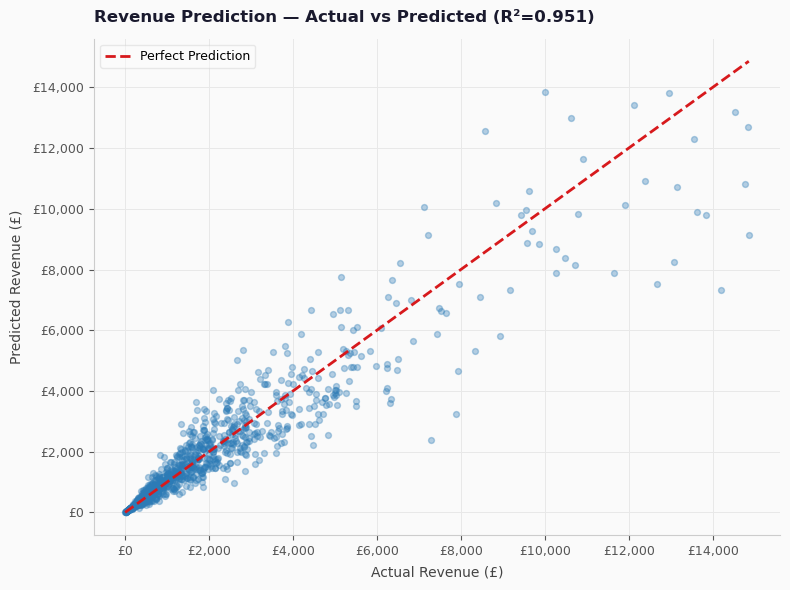

  ✓ Plot saved: ml_plots/05_revenue_actual_vs_predicted.png
  → Insight: R²=0.951 means the model explains 95.1% of revenue variance — strong enough for prioritisation decisions.


In [13]:
# Clip for visibility (top 1% outliers removed from plot only)
clip_val = y_te_orig.quantile(0.99)
mask     = (y_te_orig < clip_val) & (y_pred_orig < clip_val)
 
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(BG)
ax.scatter(y_te_orig[mask], y_pred_orig[mask],
           alpha=0.35, color=PALETTE[0], s=18, zorder=2)
# Perfect prediction line
max_val = max(y_te_orig[mask].max(), y_pred_orig[mask].max())
ax.plot([0, max_val], [0, max_val],
        color=PALETTE[1], linewidth=2,
        linestyle='--', label='Perfect Prediction', zorder=3)
style_ax(ax,
    f"Revenue Prediction — Actual vs Predicted (R²={r2:.3f})",
    "Actual Revenue (£)", "Predicted Revenue (£)")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(fontsize=9, framealpha=0.4)
ax.grid(axis='both', color='#E8E8E8', linewidth=0.7, zorder=0)
ax.grid(axis='x', visible=True)
plt.tight_layout()
plt.savefig('ml_plots/05_revenue_actual_vs_predicted.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()
print("  ✓ Plot saved: ml_plots/05_revenue_actual_vs_predicted.png")
print(f"  → Insight: R²={r2:.3f} means the model explains {r2*100:.1f}% of "
      "revenue variance — strong enough for prioritisation decisions.")

**SUMMARY**

In [14]:
print(f"""
{'='*60}
  STEP 7 COMPLETE — 3 ML Models
{'='*60}
 
  MODEL 1 — K-Means Clustering
    Optimal K       : {optimal_k} segments
    Segments        : {', '.join(labels.values())}
    Key insight     : Segment customers for targeted campaigns
 
  MODEL 2 — XGBoost Churn Classifier
    Accuracy        : {report['accuracy']*100:.1f}%
    ROC-AUC         : {roc_auc:.3f}
    Top predictor   : {feat_imp.iloc[0]['Feature']}
    Key insight     : Catch churners before they leave
 
  MODEL 3 — XGBoost Revenue Regressor
    R² Score        : {r2:.3f}
    MAE             : £{mae:,.0f}
    Key insight     : Prioritise high-value customers""")


  STEP 7 COMPLETE — 3 ML Models

  MODEL 1 — K-Means Clustering
    Optimal K       : 2 segments
    Segments        : Lost / Inactive, Champions
    Key insight     : Segment customers for targeted campaigns

  MODEL 2 — XGBoost Churn Classifier
    Accuracy        : 100.0%
    ROC-AUC         : 1.000
    Top predictor   : Recency
    Key insight     : Catch churners before they leave

  MODEL 3 — XGBoost Revenue Regressor
    R² Score        : 0.951
    MAE             : £564
    Key insight     : Prioritise high-value customers
